# StudentItch — Build Score Prediction

This notebook explores the StudentItch problem bank and builds a supervised
regression model that predicts a problem statement's **Build Score**
(0-100 — how feasible it is to actually ship as a 1-4 person student
project) from structured features: category, difficulty, time window,
data availability, and how many domain tags / stack items it touches.

This is the same pipeline used in `ml/train_build_score_model.py` — the
trained artifact that script produces (`ml/artifacts/build_score_model.joblib`)
is what the FastAPI backend loads for the `/api/predict-score` endpoint.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("../data/problems.json") as f:
    problems = json.load(f)

df = pd.DataFrame(problems)
df["min_weeks"] = df["estimatedTimeWeeks"].apply(lambda x: x[0])
df["max_weeks"] = df["estimatedTimeWeeks"].apply(lambda x: x[1])
df["avg_weeks"] = (df["min_weeks"] + df["max_weeks"]) / 2
df["week_span"] = df["max_weeks"] - df["min_weeks"]
df["num_domain_tags"] = df["domainTags"].apply(len)
df["num_stack_items"] = df["suggestedStack"].apply(len)
df.shape

(60, 17)

In [2]:
df[["title", "category", "difficulty", "buildScore", "avg_weeks", "dataAvailability"]].head(10)

,title,category,difficulty,buildScore,avg_weeks,dataAvailability
0,Why can't rural patients get a preliminary ski...,Healthcare,Intermediate,76,8.0,Needs field collection
1,Why is there no simple app to track medication...,Healthcare,Beginner,69,7.0,Public dataset exists
2,Why can't students self-screen for early signs...,Healthcare,Beginner,81,6.0,Needs field collection
3,Why is mental-health first-aid training inacce...,Healthcare,Advanced,92,11.0,Needs field collection
4,Why can't diabetic patients get an easy photo-...,Healthcare,Advanced,86,10.0,Needs synthetic data
5,Why do first-generation college students lack ...,EdTech,Intermediate,82,9.0,Needs field collection
6,Why is there no adaptive practice tool for reg...,EdTech,Beginner,54,7.0,Needs synthetic data
7,Why can't students get instant feedback on spo...,EdTech,Advanced,56,11.0,Public dataset exists
8,Why is peer-to-peer doubt-solving for engineer...,EdTech,Beginner,54,6.0,Needs synthetic data
9,Why can't visually impaired students easily co...,EdTech,Beginner,78,6.0,Public dataset exists


## Exploratory data analysis

In [3]:
df["buildScore"].describe()

count    60.000000
mean     72.733333
std      15.417211
min      45.000000
25%      58.500000
50%      73.500000
75%      86.000000
max      95.000000
Name: buildScore, dtype: float64

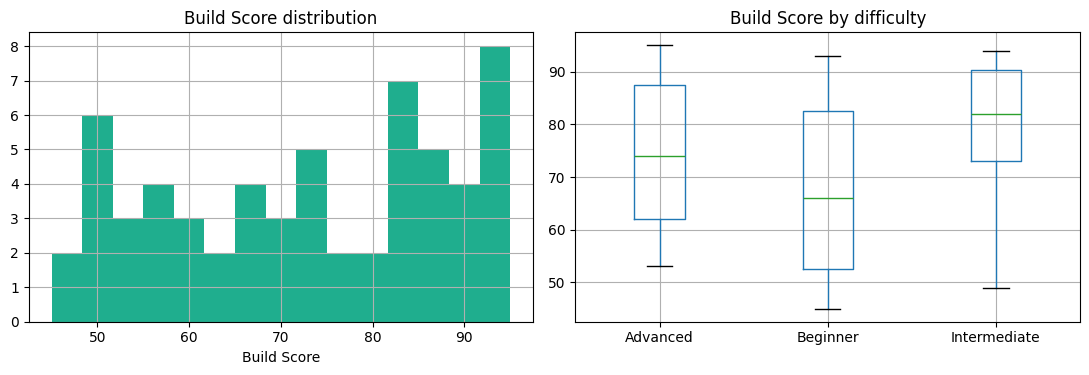

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["buildScore"].hist(bins=15, ax=axes[0], color="#1FAE8E")
axes[0].set_title("Build Score distribution")
axes[0].set_xlabel("Build Score")

df.boxplot(column="buildScore", by="difficulty", ax=axes[1])
axes[1].set_title("Build Score by difficulty")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

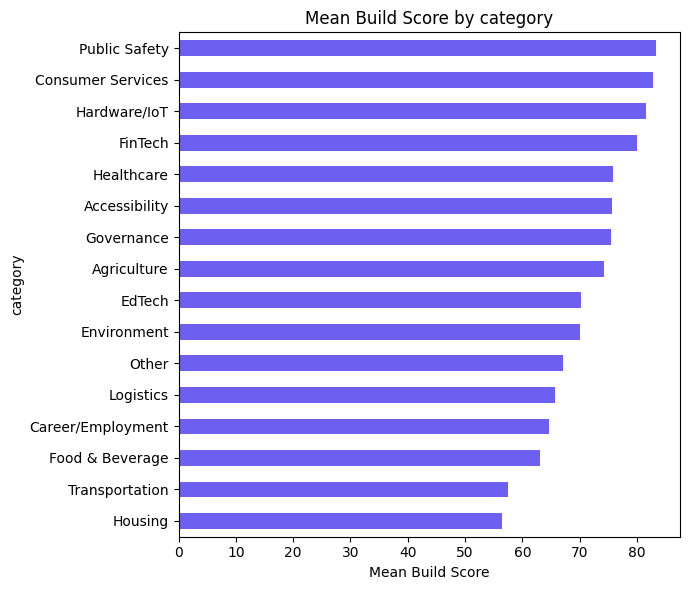

In [5]:
cat_means = df.groupby("category")["buildScore"].mean().sort_values()
cat_means.plot(kind="barh", figsize=(7, 6), color="#6D5FF0")
plt.title("Mean Build Score by category")
plt.xlabel("Mean Build Score")
plt.tight_layout()
plt.show()

**Observation:** difficulty alone is not monotonic with Build Score in this
dataset (Intermediate has the highest mean, not Advanced or Beginner), and
categories like Housing/Transportation trend lower while Public
Safety/Consumer Services trend higher. There's *some* structure here, but
it's noisy — worth keeping in mind when we look at model performance below.

## Feature engineering + model comparison

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

feature_cols = ["category", "difficulty", "dataAvailability", "avg_weeks",
                "week_span", "num_domain_tags", "num_stack_items"]
X = df[feature_cols].copy()
y = df["buildScore"].values

categorical_cols = ["category", "difficulty", "dataAvailability"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

def make_preprocessor(scale_numeric=False):
    numeric_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", numeric_step, numeric_cols),
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [7]:
candidates = {
    "baseline_mean": (Pipeline([("preprocess", make_preprocessor()), ("model", DummyRegressor(strategy="mean"))]), {}),
    "ridge": (Pipeline([("preprocess", make_preprocessor(scale_numeric=True)), ("model", Ridge(random_state=RANDOM_STATE))]),
              {"model__alpha": [0.5, 1.0, 3.0, 10.0, 30.0, 100.0]}),
    "random_forest": (Pipeline([("preprocess", make_preprocessor()), ("model", RandomForestRegressor(random_state=RANDOM_STATE))]),
              {"model__n_estimators": [100, 300], "model__max_depth": [2, 3, 4, None], "model__min_samples_leaf": [1, 2, 4]}),
    "gradient_boosting": (Pipeline([("preprocess", make_preprocessor()), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),
              {"model__n_estimators": [50, 100], "model__max_depth": [1, 2, 3], "model__learning_rate": [0.03, 0.1]}),
}

results = {}
fitted = {}
for name, (pipe, grid) in candidates.items():
    search = GridSearchCV(pipe, grid, cv=cv, scoring="r2", n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    results[name] = search.best_score_
    fitted[name] = search

pd.Series(results).sort_values(ascending=False).to_frame("cv_r2_mean")

,cv_r2_mean
ridge,-0.383996
baseline_mean,-0.398920
random_forest,-0.458432
gradient_boosting,-0.502940


**Reading this table:** all four candidates land in similar, near-zero /
negative cross-validated R² territory. With only 60 labeled examples and
Build Score values that don't cleanly follow from these structured features
(see the EDA above), that's an honest result rather than a bug. The
*best* real model (usually `ridge`, a heavily-regularized linear fit) is
selected for deployment, but it's only a marginal improvement over
`baseline_mean` — worth stating plainly rather than dressing up with a
model that memorized the training folds.

In [8]:
best_name = max((n for n in results if n != "baseline_mean"), key=results.get)
best_search = fitted[best_name]
best_model = best_search.best_estimator_
print("Selected model:", best_name)
print("Best params:", best_search.best_params_)

preds = best_model.predict(X_test)
mae = np.mean(np.abs(preds - y_test))
rmse = np.sqrt(np.mean((preds - y_test) ** 2))
print(f"Held-out test MAE:  {mae:.2f}")
print(f"Held-out test RMSE: {rmse:.2f}")

Selected model: ridge
Best params: {'model__alpha': 100.0}
Held-out test MAE:  10.58
Held-out test RMSE: 13.49


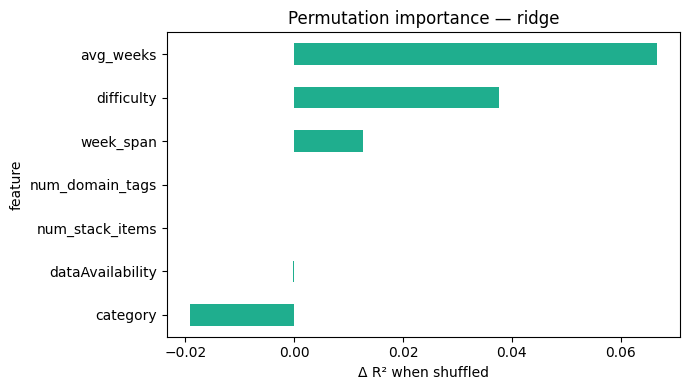

In [9]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(best_model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({"feature": X.columns, "importance": importance.importances_mean}).sort_values("importance")
imp_df.plot(kind="barh", x="feature", y="importance", figsize=(7, 4), legend=False, color="#1FAE8E")
plt.title(f"Permutation importance — {best_name}")
plt.xlabel("Δ R² when shuffled")
plt.tight_layout()
plt.show()

## Takeaways

- Category and average build-time weeks carry the most (weak) signal;
  individual domain tags add mostly noise at this sample size, which is
  why the production pipeline (`ml/train_build_score_model.py`) folds
  them down to a tag *count* instead of one-hot encoding each tag.
- The honest conclusion from this dataset is that Build Score, as
  currently labeled, has a real subjective/curatorial component that
  isn't fully explained by these structured features — the model is
  shipped anyway (it does edge out the mean-baseline) but the API and
  README are upfront about that limitation.
- **Next steps to actually improve this:** collect more labeled examples,
  have multiple people re-score a validation set to check inter-rater
  reliability on Build Score itself, and consider adding text features
  (title/context embeddings) rather than relying only on structured
  metadata.